# Thompson Sampling

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing Thompson Sampling

In [3]:
import random

# Number of rounds or trials
N = 1000

# Number of ads or options
d = 10

# List to keep track of which ads have been selected in each round
ads_selected = []

# Lists to count the number of rewards of 1 and 0 for each ad
numbers_of_rewards_1 = [0] * d
numbers_of_rewards_0 = [0] * d

# Variable to accumulate the total reward
total_reward = 0

# Iterate over each round
for n in range(0, N):
    ad = 0
    max_random = 0

    # Iterate over each ad to compute a random beta value
    for i in range(0, d):
        # Generate a random value from the Beta distribution
        # Parameters are the counts of rewards 1 and 0 for the ad
        random_beta = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)
        
        # Select the ad with the highest Beta value
        if random_beta > max_random:
            max_random = random_beta
            ad = i
    
    # Record the selected ad
    ads_selected.append(ad)
    
    # Get the reward for the selected ad from the dataset
    reward = dataset.values[n, ad]
    
    # Update the counts of rewards for the selected ad
    if reward == 1:
        numbers_of_rewards_1[ad] += 1  # Increment the count of reward 1
    else:
        numbers_of_rewards_0[ad] += 1  # Increment the count of reward 0
    
    # Accumulate the total reward
    total_reward += reward

## Visualising the results - Histogram

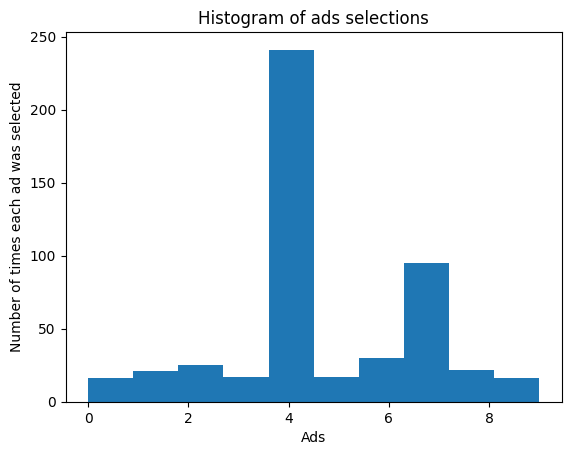

In [4]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()